In [28]:
import csv
import copy
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque, defaultdict
from itertools import count
from typing import Any, Dict, Counter, List
from dataclasses import dataclass

from torch.distributions import Categorical

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch_optimizer as optim_extra

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapperDudu import EnvWrapper

import os
import sys

sources_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if sources_path not in sys.path:
    sys.path.append(sources_path)

import Common.config as config
import Common.datatypes as datatypes
import Common.utils as utils

import importlib

importlib.reload(config)
importlib.reload(datatypes)
importlib.reload(utils)

<module 'Common.utils' from '/home/eduardo/Workspace/CacheVideoPredict360/Sources/Common/utils.py'>

In [29]:
UserTransition = datatypes.UserTransition
CachePolicy = datatypes.CachePolicy
CacheKey = datatypes.CacheKey

cfg = config.Config()
cfg.state_dim = 10 * cfg.cache_size + 10 # [x_s, x_l, y_s, y_l, z_s, z_l]
cfg.action_dim = 5 # [Base_N, Enh_N, Enh_N, Enh_N, Enh_N]
cfg.filename = f"drl_dudu_eps{cfg.epsilon_decay}_lrdecay{cfg.learning_rate_decay}_c{cfg.cache_size}_ar{cfg.arrival_rate}_z{cfg.zipf_alpha}.csv"

In [30]:
class DrlPolicy(CachePolicy):
    def __init__(self, cfg: Any = None):
        self.cfg = cfg
        self.cur_size = 0

        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]

    def get(self, key: CacheKey) -> Any:
        return self.cache.get(key, None)
    
    def put(self, vid_slot: int, value: Any, size: int) -> list:
        """
        vid_slot   -> slot index
        value -> (video_id, tiles)
        size  -> fixed as 1 slot
        """
        evicted = []
        new_video, _ = value
        
        if new_video in self.video_idx:
            old_video_slot = self.video_idx.index(new_video)
            if old_video_slot != vid_slot:
                # Swap video positions
                self.video_idx[vid_slot], self.video_idx[old_video_slot] = (
                    self.video_idx[old_video_slot],
                    self.video_idx[vid_slot],
                )

                # Swap tile mapping accordingly
                self.tile_idx[vid_slot], self.tile_idx[old_video_slot] = (
                    self.tile_idx[old_video_slot],
                    self.tile_idx[vid_slot],
                )

            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return evicted

        self.video_idx[vid_slot] = new_video
        self.tile_idx[vid_slot] = [-1] * self.cfg.viewport

        self.cur_size = sum(1 for v in self.video_idx if v != -1)
        return evicted

    def contains(self, vid: int) -> bool:
        return vid in self.video_idx

    def remove(self, vid: int) -> bool:
        if vid in self.video_idx:
            idx = self.video_idx.index(vid)
            self.video_idx[idx] = -1
            self.tile_idx[idx] = [-1] * self.cfg.viewport
            self.cur_size = sum(1 for v in self.video_idx if v != -1)
            return True
        return False

    def clear(self) -> None:
        self.video_idx = [-1] * self.cfg.cache_size
        self.tile_idx = [[-1] * self.cfg.viewport for _ in range(self.cfg.cache_size)]
        self.cur_size = 0

    def keys(self):
        return self.video_idx
    
    def get_capacity(self) -> int:
        return self.cur_size
    
    def update_size(self):
        self.cur_size = sum(1 for v in self.video_idx if v != -1)

    def stats(self) -> Dict[str, Any]:
        return {
            'current_size': self.cur_size,
            'capacity': self.cfg.cache_size,
            'num_items': len([v for v in self.video_idx if v != -1])
        }

In [31]:
class PPODebugger:
    def __init__(self):
        self.data = defaultdict(list)

    def log(self, key, value):
        if torch.is_tensor(value):
            value = value.detach().cpu().numpy()
        self.data[key].append(np.atleast_1d(value))

    def plot(self, key, title=None):
        values = np.array(self.data[key])

        plt.figure()
        plt.plot(values)
        plt.title(title or key)
        plt.xlabel("Training step")
        plt.show()
        
    def histogram(self, key, title=None):
        items = self.data.get(key, [])
        if not items:
            return

        values = np.concatenate([np.ravel(np.asarray(v)) for v in items])
        if values.size == 0:
            return

        plt.figure()
        plt.hist(values, bins=30)
        plt.title(title or key)
        plt.show()
        
    def clear(self):
        self.data.clear()

debugger = PPODebugger()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- 1. Manager: Meta-Controller (Long-term Slot Allocation) ---
class ManagerActorCritic(nn.Module):
    def __init__(self, state_dim, num_slots, hidden_dim=256):
        super(ManagerActorCritic, self).__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        self.actor = nn.Linear(hidden_dim, num_slots + 1) # Slot indices 0..C
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        features = self.backbone(state)
        logits = self.actor(features)
        value = self.critic(features)
        return logits, value

# --- 2. Worker: Sub-Controller (Fine-grained Tile Pre-fetching) ---
# Conditioned on the Manager's action via an Embedding Layer
class WorkerActorCritic(nn.Module):
    def __init__(self, state_dim, num_slots, viewport_tiles, hidden_dim=256):
        super(WorkerActorCritic, self).__init__()
        # Embed the Manager's discrete action into a continuous context
        self.slot_embedding = nn.Embedding(num_slots + 1, 16)
        
        # Combined state and embedding input
        self.backbone = nn.Sequential(
            nn.Linear(state_dim + 16, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        # One head for each tile in the viewport
        self.tile_heads = nn.ModuleList([
            nn.Linear(hidden_dim, 5) for _ in range(viewport_tiles)
        ])
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state, manager_action):
        # 1. Transform slot index into latent context
        context = self.slot_embedding(manager_action)
        # 2. Concatenate with state
        x = torch.cat([state, context], dim=-1)
        features = self.backbone(x)
        
        logits = [head(features) for head in self.tile_heads]
        value = self.critic(features)
        return logits, value

class HierarchicalPPOAgent:
    def __init__(self, state_dim, cache_size, viewport, lr_manager=1e-4, lr_worker=3e-4):
        self.manager = ManagerActorCritic(state_dim, cache_size).to(device)
        self.worker = WorkerActorCritic(state_dim, cache_size, viewport).to(device)
        
        # Separate optimizers allow different learning speeds for hierarchy levels
        self.opt_manager = optim.Adam(self.manager.parameters(), lr=lr_manager)
        self.opt_worker = optim.Adam(self.worker.parameters(), lr=lr_worker)
        
        self.eps_clip = 0.2
        self.gamma = 0.99
        self.mse_loss = nn.MSELoss()

    def select_action(self, state):
        state = torch.FloatTensor(state).to(device).unsqueeze(0)
        
        # 1. Manager Decision
        with torch.no_grad():
            m_logits, m_val = self.manager(state)
            m_dist = Categorical(logits=m_logits)
            m_action = m_dist.sample()
            m_logprob = m_dist.log_prob(m_action)
            
            # 2. Worker Decision (Conditioned on Manager)
            w_logits_list, w_val = self.worker(state, m_action)
            
            w_actions =
            w_logprobs =
            mask = (m_action > 0).float() # SVC Constraint Mask
            
            for logits in w_logits_list:
                dist = Categorical(logits=logits)
                act = dist.sample()
                # Apply hierarchy constraint: if Manager chose 0, Worker must choose 0
                final_act = act * mask.long()
                w_actions.append(final_act)
                w_logprobs.append(dist.log_prob(act) * mask)
            
            w_actions = torch.stack(w_actions, dim=1)
            w_total_lp = torch.stack(w_logprobs).sum(dim=0)
            
        return {
            'manager_action': m_action.item(),
            'worker_actions': w_actions.squeeze(0).cpu().numpy(),
            'm_logprob': m_logprob.item(),
            'w_logprob': w_total_lp.item()
        }

    def update(self, memory):
        # Implementation follows standard PPO update logic...
        # Critical Step: Calculate Manager Loss and Worker Loss separately
        # but utilize Reward Decomposition if available.
        pass

# --- 3. Reward Decomposition Helper ---
def compute_hierarchical_rewards(global_reward, info):
    """
    Decomposes the environment reward to guide specific parts of the hierarchy.
    """
    # Manager focuses on long-term cache efficiency
    manager_reward = info.get('cache_hit_rate_bl', 0.0) - 0.1 * info.get('eviction_penalty', 0)
    
    # Worker focuses on short-term viewport quality
    worker_reward = global_reward + info.get('v_psnr_gain', 0.0)
    
    return manager_reward, worker_reward

class Memory:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
    
    def clear_memory(self):
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]

In [33]:
class FeatureAdapter:
    def __init__(self, env: CacheEngineEnv, cfg: Any):
        self.env = env
        self.cfg = cfg

        self.video_hist_short = deque(maxlen=cfg.h_short)
        self.video_hist_long = deque(maxlen=cfg.h_long)
        self.tile_hist_short = deque(maxlen=cfg.h_short * cfg.viewport)
        self.tile_hist_long = deque(maxlen=cfg.h_long * cfg.viewport)

        self.video_freq_short = defaultdict(int)
        self.video_freq_long = defaultdict(int)
        self.tile_freq_short = defaultdict(int)
        self.tile_freq_long = defaultdict(int)
        
        self.ch_video_hist = deque(maxlen=cfg.h_long)
        self.ch_viewport_hist = deque(maxlen=cfg.h_long)

    def reset_history(self):
        queues = (
            self.video_hist_short,
            self.video_hist_long,
            self.tile_hist_short,
            self.tile_hist_long,
            self.ch_video_hist,
            self.ch_viewport_hist,
        )
        freqs = (
            self.video_freq_short,
            self.video_freq_long,
            self.tile_freq_short,
            self.tile_freq_long,
        )
        
        for q in queues:
            q.clear()
        for f in freqs:
            f.clear()

    def update_history(self, vid: int, tiles: list[int]):       
        self._update_window(self.video_hist_short, self.video_freq_short, vid)
        self._update_window(self.video_hist_long, self.video_freq_long, vid)

        tiles = tuple(tiles) if tiles is not None else None

        if tiles is None:
            return

        for tile in tiles:
            self._update_window(self.tile_hist_short, self.tile_freq_short, (vid, tile))
            self._update_window(self.tile_hist_long, self.tile_freq_long, (vid, tile))

    def update_history_single(self, item):
        if isinstance(item, int):
            self._update_window(self.video_hist_short, self.video_freq_short, item)
            self._update_window(self.video_hist_long, self.video_freq_long, item)
        elif isinstance(item, tuple) and len(item) == 2:
            self._update_window(self.tile_hist_short, self.tile_freq_short, item)
            self._update_window(self.tile_hist_long, self.tile_freq_long, item)


    def update_ch_history(self, vid: int, viewport: list[int]):
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        hit = 1 if vid in video_cache_index else 0
        self.ch_video_hist.append(hit)
        
        if not hit:
            viewport_vector = [0,0,0,0]
        else:
            idx = video_cache_index.index(vid)
            cached_tiles = tile_cache_index[idx]
            viewport_vector = [1 if tile in cached_tiles else 0 for tile in viewport]
            
        self.ch_viewport_hist.append(viewport_vector)
        return hit + sum(viewport_vector)
    
    def compute_reward(self) -> float:
        psnr_layer_0 = 30 * sum(self.ch_video_hist)
        psnr_layer_1 = 2.5 * sum(sum(viewport) for viewport in self.ch_viewport_hist)
        
        return (psnr_layer_0 + psnr_layer_1) / len(self.ch_video_hist)
        
    def _update_window(self, hist_queue: deque, freq_dict: Dict, item):
        if len(hist_queue) == hist_queue.maxlen:
            old_item = hist_queue.popleft()
            freq_dict[old_item] -= 1
            if freq_dict[old_item] == 0:
                del freq_dict[old_item]
        hist_queue.append(item)
        freq_dict[item] += 1

In [ ]:
class NetworkAdapter:
    def __init__(self, env: EnvWrapper, feature_adapter: FeatureAdapter, cfg: Any):
        self.env = env
        self.cfg = cfg
        self.features = feature_adapter

        self.C = self.cfg.cache_size  # paper's cache capacity (videos)
        self.k = self.cfg.viewport    # paper's tiles per video (enhancement)

        print(f"NetworkAdapter initialized with capacity: {self.C} videos, {self.k} tiles per video")

    def build_observation(self, vid: int, viewport: list) -> np.ndarray:
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        x_s = np.zeros(self.C, dtype=np.float32)
        x_l = np.zeros(self.C, dtype=np.float32)

        y_s = np.zeros(self.C * self.k, dtype=np.float32)
        y_l = np.zeros(self.C * self.k, dtype=np.float32)

        for vid_i, v in enumerate(video_cache_index):
            if v == -1:
                continue
            x_s[vid_i] = self.features.video_freq_short.get(v, 0)
            x_l[vid_i] = self.features.video_freq_long.get(v, 0)

            tiles = tile_cache_index[vid_i]

            for til_i, t in enumerate(tiles):
                if t == -1:
                    continue
                y_s[vid_i * self.k + til_i] = self.features.tile_freq_short.get((v, t), 0)
                y_l[vid_i * self.k + til_i] = self.features.tile_freq_long.get((v, t), 0)


        if viewport is None:
            z_s = np.array(
                [self.features.video_freq_short.get(vid, 0)], dtype=np.float32
            )
            z_l = np.array(
                [self.features.video_freq_long.get(vid, 0)], dtype=np.float32
            )
        else:
            z_s = np.zeros(len(viewport) + 1, dtype=np.float32)
            z_l = np.zeros(len(viewport) + 1, dtype=np.float32)

            for vp_i, vp in enumerate(viewport):
                z_s[vp_i + 1] = self.features.tile_freq_short.get((vid, vp), 0)
                z_l[vp_i + 1] = self.features.tile_freq_long.get((vid, vp), 0)

        features = np.concatenate([x_s, x_l, y_s, y_l, z_s, z_l], axis=0)
        return features
    
    def reset(self):
        
        obs, info = self.env.reset()
        self.features.reset_history()

        return obs, info
    
    def env_is_done(self) -> bool:
        return self.env.users_env.all_users_done()

In [35]:
def save_training_results(
    path_,
    filename,
    ep, 
    total_reward, 
    cache_hits, 
    cache_misses, 
    soft_hits,
    agent
):
    with open(os.path.join(path_, filename), 'a', newline='') as f:
        fieldnames = [
            'episode', 
            'total_reward', 
            'cache_hits', 
            'cache_misses', 
            'soft_hits',
            'epsilon',
            'lr'
        ]
        writer_results = csv.DictWriter(f, fieldnames=fieldnames)

        if ep == 1:
            writer_results.writeheader()
        
        writer_results.writerow({
            'episode': ep,
            'total_reward': round(float(total_reward), 2),
            'cache_hits': cache_hits,
            'cache_misses': cache_misses,
            'soft_hits': soft_hits,
            'lr': f"{agent.scheduler.get_last_lr()[0]:.10f}" if agent else None,
            'epsilon': round(float(agent.entropy_coef), 4) if agent else None
        })

def update_metrics(info: dict, reward: float) -> tuple[float, int, int, float]:
    enh_hits = info.get("enh_layer_hits", 0)
    base_hits = info.get("base_layer_hits", 0)
    enh_misses = info.get("enh_layer_misses", 0)
    base_misses = info.get("base_layer_misses", 0)
    soft_hits = info.get("soft_hits", 0.0)

    return reward, (enh_hits + base_hits), (enh_misses + base_misses), soft_hits

def build_latency_model(cfg):
    """Build and return the MultiDULatencyModel."""
    P = cfg.n_nodes
    max_U = cfg.n_users

    return MultiDULatencyModel(
        P=P,
        max_U=max_U,
        R_M_D=80e6,
        R_C_M=125e6,
        mu=2e7,
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 20e6, dtype=float),
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),
        rhoT_p=[0.2],
        lambda_p=[0.05],
        du_fixed_delay=0.001,
        mec_fixed_delay=0.005,
        cloud_fixed_delay=0.1
    )

def build_environment(cfg):
    """Construct the full multi-component environment wrapper."""
    du_caches = []

    # DRL Caching Policy
    policy = DrlPolicy(cfg=cfg)

    # MEC Cache Engine
    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
        policy=policy
    )

    # User request generator
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        m=cfg.m,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha
    )

    # Latency Model
    latency_model = build_latency_model(cfg)

    # Wrapping all into the main training environment
    return EnvWrapper(
        cfg=cfg,
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env,
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=latency_model,
        theta=cfg.theta,
        lam=cfg.lam,
        max_steps=cfg.max_steps,
        prefetch_fn=lambda cache, action: cache.drl_prefetching_dudu(action),
        reward_fn=lambda env, reqs: env.compute_reward(reqs)
    )

NetworkAdapter initialized with capacity: 50 videos, 4 tiles per video
Episode 1 | Step 1 | Action: [28  4  1  0  0] | LogProb: -18.8564
Episode 1 | Step 2 | Action: [2 3 1 0 2] | LogProb: -19.3324
Episode 1 | Step 3 | Action: [39  0  4  4  3] | LogProb: -18.7830
Episode 1 | Step 4 | Action: [22  0  1  1  4] | LogProb: -19.0519
Episode 1 | Step 5 | Action: [48  1  4  4  1] | LogProb: -19.0485
Episode 1 | Step 6 | Action: [9 4 4 1 2] | LogProb: -18.7559
Episode 1 | Step 7 | Action: [42  2  0  0  2] | LogProb: -19.2571
Episode 1 | Step 8 | Action: [4 2 0 4 4] | LogProb: -18.7072
Episode 1 | Step 9 | Action: [17  4  2  4  4] | LogProb: -19.0028
Episode 1 | Step 10 | Action: [13  2  3  0  3] | LogProb: -18.8941
Episode 1 | Step 11 | Action: [26  0  4  3  3] | LogProb: -18.7905
Episode 1 | Step 12 | Action: [33  0  4  3  1] | LogProb: -19.0334
Episode 1 | Step 13 | Action: [38  0  0  4  1] | LogProb: -18.6742
Episode 1 | Step 14 | Action: [24  2  4  4  4] | LogProb: -19.2576
Episode 1 | Ste

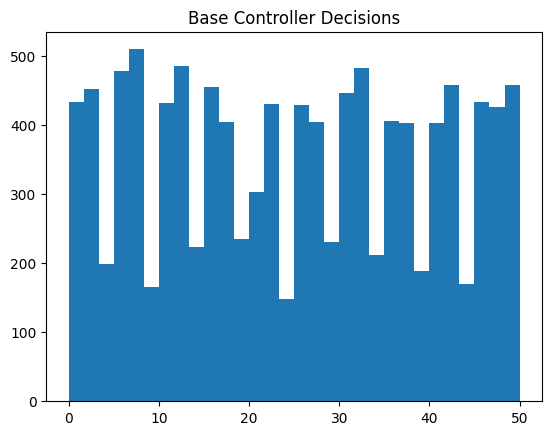

--- Episode 1 completed | Total Reward: 203446.15 | Hit Rate: 0.48 ---
Episode 2 | Step 1 | Action: [16  1  3  4  3] | LogProb: -18.8249
Episode 2 | Step 2 | Action: [10  3  3  2  3] | LogProb: -18.4669
Episode 2 | Step 3 | Action: [24  0  3  0  4] | LogProb: -18.7986
Episode 2 | Step 4 | Action: [19  2  3  0  3] | LogProb: -19.0036
Episode 2 | Step 5 | Action: [41  0  1  1  1] | LogProb: -18.5515
Episode 2 | Step 6 | Action: [47  0  1  1  0] | LogProb: -19.0479
Episode 2 | Step 7 | Action: [25  4  4  0  3] | LogProb: -18.2024
Episode 2 | Step 8 | Action: [12  0  2  3  3] | LogProb: -17.7835
Episode 2 | Step 9 | Action: [6 3 0 0 0] | LogProb: -19.5755
Episode 2 | Step 10 | Action: [31  3  4  0  2] | LogProb: -18.4964
Episode 2 | Step 11 | Action: [27  3  1  0  4] | LogProb: -18.1434
Episode 2 | Step 12 | Action: [48  3  0  0  4] | LogProb: -18.8088
Episode 2 | Step 13 | Action: [18  4  2  1  2] | LogProb: -18.1977
Episode 2 | Step 14 | Action: [41  1  2  1  3] | LogProb: -18.1877
Episo

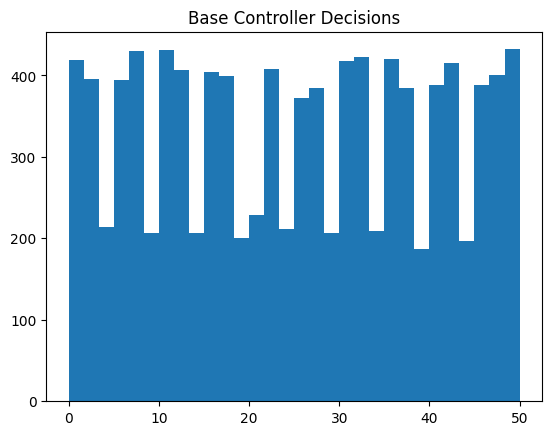

--- Episode 2 completed | Total Reward: 196565.69 | Hit Rate: 0.49 ---
Episode 3 | Step 1 | Action: [12  1  0  2  0] | LogProb: -19.0588
Episode 3 | Step 2 | Action: [16  1  2  2  3] | LogProb: -18.8855
Episode 3 | Step 3 | Action: [10  3  4  0  4] | LogProb: -18.4191
Episode 3 | Step 4 | Action: [25  0  0  1  0] | LogProb: -18.3323
Episode 3 | Step 5 | Action: [37  3  2  3  2] | LogProb: -18.5780
Episode 3 | Step 6 | Action: [20  0  1  1  2] | LogProb: -18.8587
Episode 3 | Step 7 | Action: [41  1  2  4  3] | LogProb: -18.5390
Episode 3 | Step 8 | Action: [22  1  3  3  0] | LogProb: -19.4914
Episode 3 | Step 9 | Action: [39  3  3  1  0] | LogProb: -17.9927
Episode 3 | Step 10 | Action: [5 0 1 3 4] | LogProb: -18.9610
Episode 3 | Step 11 | Action: [20  1  2  1  2] | LogProb: -18.8360
Episode 3 | Step 12 | Action: [1 4 2 3 4] | LogProb: -17.5793
Episode 3 | Step 13 | Action: [25  4  3  4  2] | LogProb: -18.6079
Episode 3 | Step 14 | Action: [16  0  2  0  0] | LogProb: -19.5135
Episode 3 

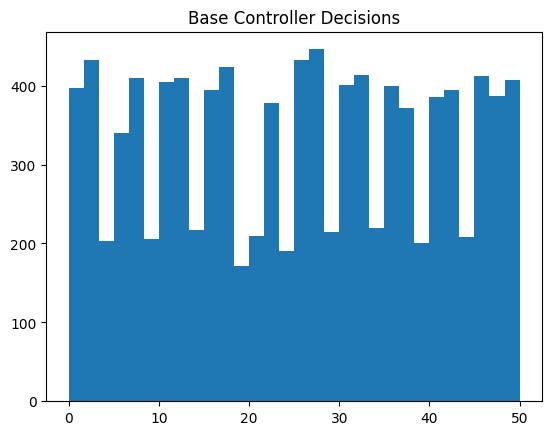

--- Episode 3 completed | Total Reward: 191701.05 | Hit Rate: 0.49 ---
Episode 4 | Step 1 | Action: [12  4  2  1  2] | LogProb: -18.8911
Episode 4 | Step 2 | Action: [26  3  1  1  3] | LogProb: -18.8036
Episode 4 | Step 3 | Action: [43  2  4  1  2] | LogProb: -18.8728
Episode 4 | Step 4 | Action: [46  3  3  1  4] | LogProb: -18.7880
Episode 4 | Step 5 | Action: [35  4  1  2  3] | LogProb: -18.3367
Episode 4 | Step 6 | Action: [31  1  0  2  4] | LogProb: -19.1436
Episode 4 | Step 7 | Action: [1 3 0 1 4] | LogProb: -17.7380
Episode 4 | Step 8 | Action: [38  3  0  0  4] | LogProb: -18.6600
Episode 4 | Step 9 | Action: [29  3  0  4  2] | LogProb: -18.1394
Episode 4 | Step 10 | Action: [2 1 2 1 4] | LogProb: -18.9660
Episode 4 | Step 11 | Action: [37  4  2  3  2] | LogProb: -18.8967
Episode 4 | Step 12 | Action: [8 1 2 4 2] | LogProb: -18.6027
Episode 4 | Step 13 | Action: [24  0  3  1  4] | LogProb: -18.7011
Episode 4 | Step 14 | Action: [7 2 0 1 3] | LogProb: -18.3418
Episode 4 | Step 15 

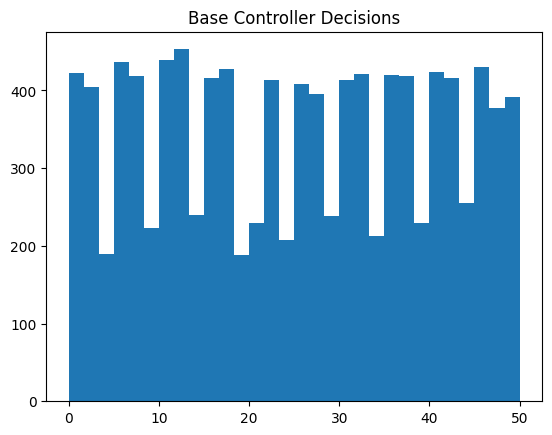

--- Episode 4 completed | Total Reward: 210445.71 | Hit Rate: 0.51 ---
Episode 5 | Step 1 | Action: [31  4  0  1  0] | LogProb: -18.8612
Episode 5 | Step 2 | Action: [2 3 3 0 3] | LogProb: -19.1343
Episode 5 | Step 3 | Action: [11  1  1  0  3] | LogProb: -18.4108
Episode 5 | Step 4 | Action: [0 3 4 0 0] | LogProb: -19.6659
Episode 5 | Step 5 | Action: [2 4 3 3 3] | LogProb: -19.0599
Episode 5 | Step 6 | Action: [18  2  1  3  0] | LogProb: -18.8544
Episode 5 | Step 7 | Action: [50  3  3  0  4] | LogProb: -19.2186
Episode 5 | Step 8 | Action: [20  1  1  1  3] | LogProb: -18.2686
Episode 5 | Step 9 | Action: [3 4 2 3 3] | LogProb: -18.4545
Episode 5 | Step 10 | Action: [47  4  1  4  4] | LogProb: -19.4237
Episode 5 | Step 11 | Action: [24  1  4  3  0] | LogProb: -18.6237
Episode 5 | Step 12 | Action: [7 3 1 1 3] | LogProb: -17.5308
Episode 5 | Step 13 | Action: [19  2  0  3  2] | LogProb: -19.3229
Episode 5 | Step 14 | Action: [14  1  3  0  3] | LogProb: -18.8104
Episode 5 | Step 15 | Act

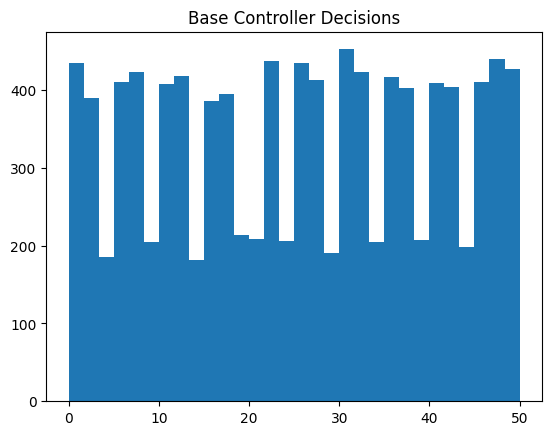

--- Episode 5 completed | Total Reward: 213172.96 | Hit Rate: 0.53 ---
Episode 6 | Step 1 | Action: [4 2 1 2 1] | LogProb: -18.8217
Episode 6 | Step 2 | Action: [37  0  0  3  2] | LogProb: -18.8065
Episode 6 | Step 3 | Action: [40  0  3  4  4] | LogProb: -18.8093
Episode 6 | Step 4 | Action: [50  0  2  1  0] | LogProb: -19.5382
Episode 6 | Step 5 | Action: [7 4 2 1 4] | LogProb: -18.7001
Episode 6 | Step 6 | Action: [33  0  4  4  0] | LogProb: -18.8204
Episode 6 | Step 7 | Action: [23  4  0  0  4] | LogProb: -18.6784
Episode 6 | Step 8 | Action: [38  0  2  0  1] | LogProb: -19.1823
Episode 6 | Step 9 | Action: [9 4 1 4 1] | LogProb: -20.0452
Episode 6 | Step 10 | Action: [10  4  4  0  4] | LogProb: -18.4580
Episode 6 | Step 11 | Action: [43  2  1  0  3] | LogProb: -18.9757
Episode 6 | Step 12 | Action: [43  2  2  0  4] | LogProb: -18.9634
Episode 6 | Step 13 | Action: [9 0 2 0 1] | LogProb: -20.0370
Episode 6 | Step 14 | Action: [46  3  1  3  2] | LogProb: -18.5537
Episode 6 | Step 15 

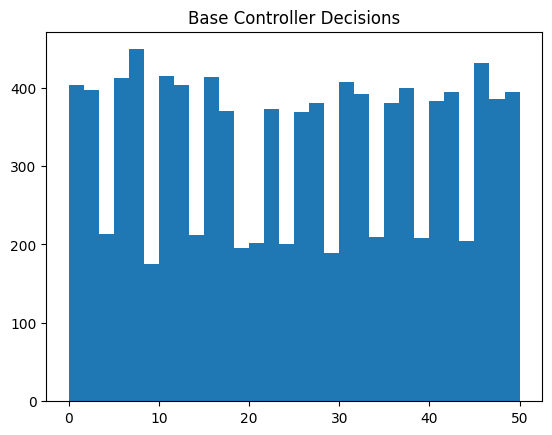

--- Episode 6 completed | Total Reward: 213079.70 | Hit Rate: 0.54 ---
Episode 7 | Step 1 | Action: [7 1 2 0 2] | LogProb: -18.9227
Episode 7 | Step 2 | Action: [46  1  2  4  3] | LogProb: -19.0670
Episode 7 | Step 3 | Action: [27  2  1  1  3] | LogProb: -19.3271
Episode 7 | Step 4 | Action: [45  2  0  4  3] | LogProb: -18.9059
Episode 7 | Step 5 | Action: [7 3 2 1 2] | LogProb: -18.6169
Episode 7 | Step 6 | Action: [30  1  2  1  2] | LogProb: -18.6046
Episode 7 | Step 7 | Action: [36  4  3  2  4] | LogProb: -18.6837
Episode 7 | Step 8 | Action: [20  0  0  3  0] | LogProb: -18.8985
Episode 7 | Step 9 | Action: [18  0  0  3  0] | LogProb: -18.3612
Episode 7 | Step 10 | Action: [40  3  0  3  1] | LogProb: -18.6053
Episode 7 | Step 11 | Action: [22  3  1  0  2] | LogProb: -18.1485
Episode 7 | Step 12 | Action: [23  4  2  2  0] | LogProb: -18.8274
Episode 7 | Step 13 | Action: [25  2  2  3  0] | LogProb: -19.0775
Episode 7 | Step 14 | Action: [25  2  0  2  2] | LogProb: -19.3931
Episode 7 

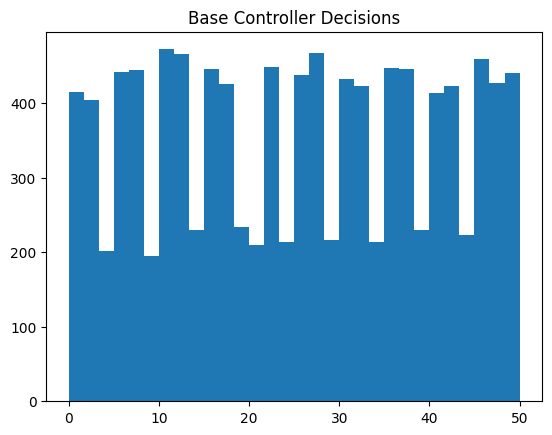

--- Episode 7 completed | Total Reward: 210568.33 | Hit Rate: 0.49 ---
Episode 8 | Step 1 | Action: [10  1  3  4  4] | LogProb: -19.2450
Episode 8 | Step 2 | Action: [3 1 0 1 2] | LogProb: -19.5065
Episode 8 | Step 3 | Action: [43  1  4  1  3] | LogProb: -17.6121
Episode 8 | Step 4 | Action: [11  0  4  1  4] | LogProb: -17.8343
Episode 8 | Step 5 | Action: [6 0 1 1 3] | LogProb: -16.1840
Episode 8 | Step 6 | Action: [28  0  0  0  3] | LogProb: -17.0085
Episode 8 | Step 7 | Action: [41  0  1  3  3] | LogProb: -15.8047
Episode 8 | Step 8 | Action: [13  0  1  3  3] | LogProb: -15.5301
Episode 8 | Step 9 | Action: [39  0  2  0  3] | LogProb: -15.3363
Episode 8 | Step 10 | Action: [42  0  1  3  4] | LogProb: -17.7671
Episode 8 | Step 11 | Action: [6 0 2 3 3] | LogProb: -14.5306
Episode 8 | Step 12 | Action: [3 0 1 3 3] | LogProb: -18.0303
Episode 8 | Step 13 | Action: [12  0  2  0  2] | LogProb: -17.1628
Episode 8 | Step 14 | Action: [4 2 2 0 1] | LogProb: -20.8105
Episode 8 | Step 15 | Act

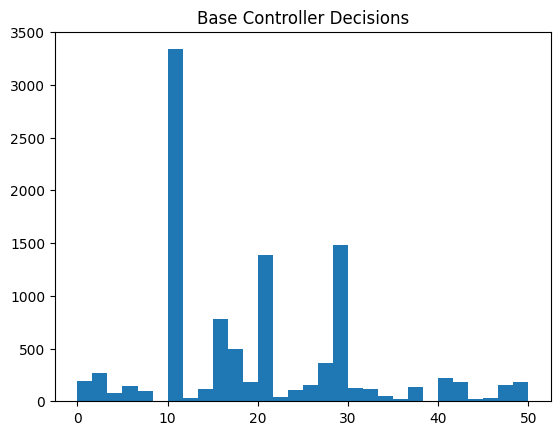

--- Episode 8 completed | Total Reward: 113376.48 | Hit Rate: 0.25 ---
Episode 9 | Step 1 | Action: [11  1  4  4  1] | LogProb: -0.0984
Episode 9 | Step 2 | Action: [11  1  4  4  1] | LogProb: -0.0006
Episode 9 | Step 3 | Action: [11  1  4  4  1] | LogProb: -0.0006
Episode 9 | Step 4 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 5 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 6 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 7 | Action: [11  1  4  4  1] | LogProb: -0.0004
Episode 9 | Step 8 | Action: [11  1  4  4  1] | LogProb: -0.0006
Episode 9 | Step 9 | Action: [11  1  4  4  1] | LogProb: -0.0006
Episode 9 | Step 10 | Action: [11  1  4  4  1] | LogProb: -0.0006
Episode 9 | Step 11 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 12 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 13 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | Step 14 | Action: [11  1  4  4  1] | LogProb: -0.0003
Episode 9 | St

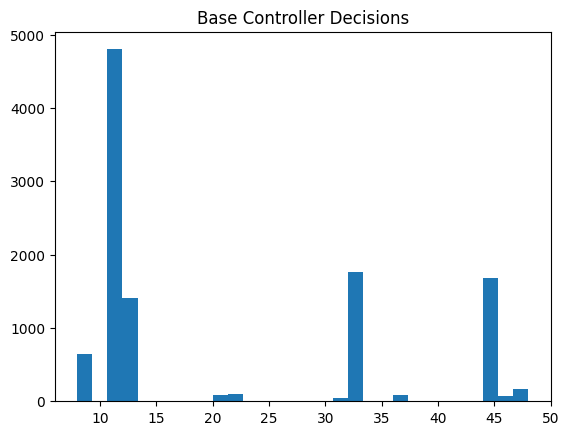

--- Episode 9 completed | Total Reward: 26770.32 | Hit Rate: 0.07 ---
Episode 10 | Step 1 | Action: [33  4  2  0  4] | LogProb: -7.7531
Episode 10 | Step 2 | Action: [45  4  1  0  4] | LogProb: -0.9009
Episode 10 | Step 3 | Action: [45  4  1  0  4] | LogProb: -3.2441
Episode 10 | Step 4 | Action: [45  4  1  0  4] | LogProb: -0.9270
Episode 10 | Step 5 | Action: [45  4  1  0  4] | LogProb: -1.9071
Episode 10 | Step 6 | Action: [33  4  1  0  4] | LogProb: -3.2701
Episode 10 | Step 7 | Action: [45  4  1  0  4] | LogProb: -2.2739
Episode 10 | Step 8 | Action: [12  4  1  0  4] | LogProb: -10.2518
Episode 10 | Step 9 | Action: [45  4  1  0  4] | LogProb: -3.0098
Episode 10 | Step 10 | Action: [33  4  1  0  4] | LogProb: -3.5475
Episode 10 | Step 11 | Action: [33  4  1  0  4] | LogProb: -2.9811
Episode 10 | Step 12 | Action: [45  4  1  0  4] | LogProb: -3.6600
Episode 10 | Step 13 | Action: [45  4  1  0  4] | LogProb: -3.6334
Episode 10 | Step 14 | Action: [45  4  1  0  4] | LogProb: -3.6334


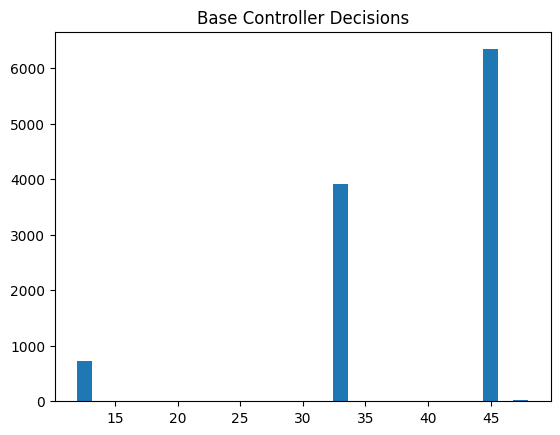

--- Episode 10 completed | Total Reward: 20437.24 | Hit Rate: 0.04 ---
Episode 11 | Step 1 | Action: [45  4  2  0  3] | LogProb: -4.0209
Episode 11 | Step 2 | Action: [45  4  1  0  4] | LogProb: -1.8909
Episode 11 | Step 3 | Action: [45  4  1  0  4] | LogProb: -2.7050
Episode 11 | Step 4 | Action: [45  4  1  0  4] | LogProb: -2.7050
Episode 11 | Step 5 | Action: [33  4  1  0  4] | LogProb: -3.9388
Episode 11 | Step 6 | Action: [33  4  1  0  4] | LogProb: -4.0726
Episode 11 | Step 7 | Action: [45  4  1  0  4] | LogProb: -1.8183
Episode 11 | Step 8 | Action: [33  4  1  0  4] | LogProb: -3.8712
Episode 11 | Step 9 | Action: [45  4  1  0  4] | LogProb: -2.0384
Episode 11 | Step 10 | Action: [45  4  1  0  4] | LogProb: -1.9537
Episode 11 | Step 11 | Action: [33  4  1  0  4] | LogProb: -3.9381
Episode 11 | Step 12 | Action: [45  4  1  0  4] | LogProb: -1.7467
Episode 11 | Step 13 | Action: [45  4  1  0  4] | LogProb: -1.9231
Episode 11 | Step 14 | Action: [33  4  1  0  4] | LogProb: -4.0545


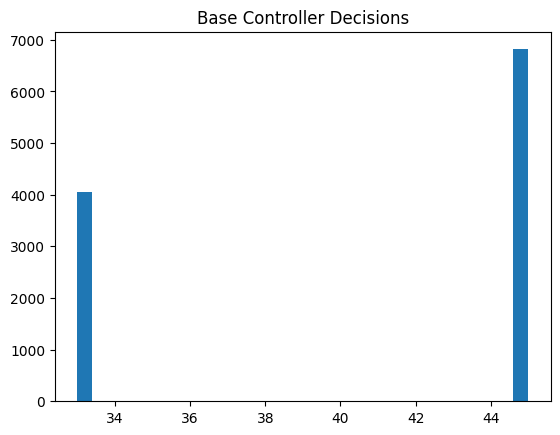

--- Episode 11 completed | Total Reward: 7588.73 | Hit Rate: 0.03 ---
Episode 12 | Step 1 | Action: [33  4  1  0  0] | LogProb: -6.3639
Episode 12 | Step 2 | Action: [33  4  1  0  4] | LogProb: -3.9899
Episode 12 | Step 3 | Action: [33  4  1  0  4] | LogProb: -3.8914
Episode 12 | Step 4 | Action: [45  4  1  0  4] | LogProb: -1.8977
Episode 12 | Step 5 | Action: [45  4  1  0  4] | LogProb: -2.0598
Episode 12 | Step 6 | Action: [33  4  1  0  4] | LogProb: -4.3397
Episode 12 | Step 7 | Action: [45  4  1  0  4] | LogProb: -1.9011
Episode 12 | Step 8 | Action: [45  4  1  0  4] | LogProb: -1.8884
Episode 12 | Step 9 | Action: [45  4  1  0  4] | LogProb: -1.7158
Episode 12 | Step 10 | Action: [45  4  1  0  4] | LogProb: -2.1468
Episode 12 | Step 11 | Action: [45  4  1  0  4] | LogProb: -1.8870
Episode 12 | Step 12 | Action: [45  4  1  0  4] | LogProb: -2.1960
Episode 12 | Step 13 | Action: [45  4  1  0  4] | LogProb: -1.6912
Episode 12 | Step 14 | Action: [33  4  1  0  4] | LogProb: -3.9271
E

KeyboardInterrupt: 

In [ ]:
def run_episode(episode, env, agent, net_adapter, cfg):
    """Run one full training episode."""
    _, info = net_adapter.reset()
    agent.reset_step()

    cache_hits = cache_misses = 0
    soft_hits = total_reward = 0.0

    memory = Memory()
    
    for step in count(start=1, step=1):

        req_state = info["user_request"]
        video = req_state["video"]
        viewport = req_state["viewport"]

        state = net_adapter.build_observation(video, viewport)
        state = np.log1p(state)  # Log-transform for better scaling
        
        action, log_prob = agent.select_action(state)

        debugger.log("base_action", action[0])
        for i, act in enumerate(action[1:]):
            debugger.log(f"enh_action_{i}", act)

        print(f"Episode {episode} | Step {step} | Action: {action} | LogProb: {log_prob:.4f}")

        net_adapter.features.update_history(video,viewport)
        net_adapter.features.update_ch_history(video, viewport)

        _, reward, _, info = env.step(action, req_state)
                
        reward = net_adapter.features.compute_reward()

        done = env.users_env.all_users_done()

        # Store in memory
        memory.states.append(torch.FloatTensor(state))
        memory.actions.append(torch.from_numpy(action))
        memory.logprobs.append(torch.FloatTensor([log_prob]))
        memory.rewards.append(reward)
        memory.is_terminals.append(done)

        # PPO Update
        if step % cfg.nb_interval == 0:
            agent.update(memory)
            memory.clear_memory()

        delta_r, hits, misses, soft = update_metrics(info, reward)
        total_reward += delta_r
        cache_hits   += hits
        cache_misses += misses
        soft_hits    += soft

        if net_adapter.env_is_done():
            break

    debugger.histogram("base_action", "Base Controller Decisions")
    debugger.clear()
    
    return total_reward, cache_hits, cache_misses, soft_hits

def train(cfg):

    env = build_environment(cfg)
    agent = HierarchicalPPOAgent(cfg)

    feature_adapter = FeatureAdapter(env, cfg)
    net_adapter = NetworkAdapter(env, feature_adapter, cfg)

    for episode in range(1, cfg.n_episodes + 1):

        total_reward, hits, misses, soft = run_episode(
            episode, env, agent, net_adapter, cfg
        )

        if episode % 20 == 0:
            new_coef = agent.decay_entropy_coef(decay_rate=0.9)
            
        save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=episode,
            total_reward=total_reward,
            cache_hits=hits,
            cache_misses=misses,
            soft_hits=soft,
            agent=agent
        )

        hit_rate = hits / (hits + misses) if (hits + misses) > 0 else 0.0
        print(f"--- Episode {episode} completed | Total Reward: {total_reward:.2f} | Hit Rate: {hit_rate:.2f} ---")


if __name__ == "__main__":
    train(cfg)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
# cfg.filename = "drl_pan_eps0.98_lrdecay0.9999_c50_ar200.0_z0.8.csv"
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 1  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value") 
    
    series = df[col].dropna()
    if not series.empty:
        ymin = series.min()
        ymax = series.max()
        pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
        ax.set_ylim(bottom=0)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)

In [ ]:
if __name__ == "__main__":
    cfg = config.Config()

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True
    })

    COLORS = ["#2b7bba", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]

    folder = r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results"
    folder= cfg.path_results
    
    files = [
        "drl_pan_eps0.985_lrdecay0.9995_c50_ar200.0_z0.8.csv",
        "drl_pan_eps0.98_lrdecay0.9999_c50_ar200.0_z0.8.csv",
        "drl_pan_eps0.97_lrdecay0.9997_c50_ar200.0_z0.8.csv",
        # "drl_pan_eps0.97_lrdecay0.9997_c100_ar200.0_z0.8.csv"
    ]

    paths = [os.path.join(folder, f) for f in files]
    def _short_label(fname: str) -> str:
        stem = os.path.splitext(fname)[0]
        if "lrdecay" in stem:
            val = stem.split("lrdecay", 1)[1].split("_", 1)[0]
            return f"lr decay: {val}"
        if "fixedlr" in stem:
            val = stem.split("fixedlr", 1)[1].split("_", 1)[0]
            return f"fixed lr: {val}"
        return stem

    labels = [_short_label(f) for f in files]

    print(labels)
    metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
    window_size = 1

    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

    for color, path, label in zip(COLORS, paths, labels):
        df = pd.read_csv(path).head(100).copy()   # only first 100 values
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        df["hit_rate"] = (df["cache_hits"] / total) * 100
        df["miss_rate"] = (df["cache_misses"] / total) * 100

        for ax, col in zip(axes, metrics):
            ax.plot(df["episode"], df[col], color=color, alpha=0.25, linewidth=0.8)

            if col != "epsilon":
                smoothed = df[col].rolling(window=window_size).mean()
                ax.plot(df["episode"], smoothed, color=color, linewidth=1.5, label=label)
            else:
                ax.plot(df["episode"], df[col], color=color, linewidth=1.5, label=label)

    for ax, col in zip(axes, metrics):
        ax.set_title(col.replace("_", " ").title(), fontweight="bold")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Value")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.set_ylim(bottom=0)

    axes[0].legend(frameon=False, loc="best")
    plt.show()

    fig.savefig("interval_04_comparison.png", dpi=300)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

COLORS = ["#2b7bba", "#d62728"]

# ----------------------------------------------------------------
# 2. Data Preparation with Variance
# ----------------------------------------------------------------
def get_metrics_with_error(path):
    """Returns mean and standard deviation for hit and miss rates."""
    try:
        df = pd.read_csv(path)
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        
        hit_series = (df["cache_hits"] / total * 100)
        miss_series = (df["cache_misses"] / total * 100)
        
        # Calculate Mean and Standard Deviation
        return (hit_series.mean(), hit_series.std()), (miss_series.mean(), miss_series.std())
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return (0, 0), (0, 0)

drl_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c50_ar10.0_z0.5.csv",
}

lsr_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c50_ar10.0_z0.5.csv",
}

caps = list(drl_files.keys())
# Structure: { Metric: { Algo: [means], Algo_err: [stds] } }
stats = {
    "Hit Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []},
    "Miss Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []}
}

for c in caps:
    (d_h, d_h_err), (d_m, d_m_err) = get_metrics_with_error(drl_files[c])
    (l_h, l_h_err), (l_m, l_m_err) = get_metrics_with_error(lsr_files[c])
    
    stats["Hit Rate"]["DRL-LSR"].append(d_h)
    stats["Hit Rate"]["DRL-LSR_err"].append(d_h_err)
    stats["Hit Rate"]["LRU-LSR"].append(l_h)
    stats["Hit Rate"]["LRU-LSR_err"].append(l_h_err)
    
    stats["Miss Rate"]["DRL-LSR"].append(d_m)
    stats["Miss Rate"]["DRL-LSR_err"].append(d_m_err)
    stats["Miss Rate"]["LRU-LSR"].append(l_m)
    stats["Miss Rate"]["LRU-LSR_err"].append(l_m_err)

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)
x = np.arange(len(caps))
width = 0.35 

# Error bar styling
error_kw = dict(lw=1, capsize=3, capthick=1, ecolor='#333333')

metrics = ["Hit Rate", "Miss Rate"]
for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.bar(x - width/2, stats[metric]["DRL-LSR"], width, 
           yerr=stats[metric]["DRL-LSR_err"], error_kw=error_kw,
           label="DRL-LSR", color=COLORS[0], edgecolor='black', linewidth=0.6, zorder=3)
    
    ax.bar(x + width/2, stats[metric]["LRU-LSR"], width, 
           yerr=stats[metric]["LRU-LSR_err"], error_kw=error_kw,
           label="LRU-LSR", color=COLORS[1], edgecolor='black', linewidth=0.6, zorder=3)

    ax.set_title(f"Average {metric}", fontweight="bold")
    ax.set_xlabel("Cache Size (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(caps)
    ax.set_ylim(0, 110) # Increased to accommodate error bars
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

fig.savefig("drl_vs_lru_cache_performance.pdf")